# Network Science Assignment 5

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 28. October 2024

In [1]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import glob

In [2]:
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

For the provided network datasets find the communities using (a) the greedy modularity maximization by Clauset Newman and Moore Clauset et al. [2004] and (b) the label propagation algorithm.
Assign to each community a color and draw the resulting graph, where each node is colored after the community it belongs to, while community internal links and inter‑communities links are clearly recognizable.


In [3]:
def greedy_modularity_maximization(G): 
    communities = nx.community.greedy_modularity_communities(G)
    return communities


def label_propagation(G):
    communities = nx.community.label_propagation_communities(G)
    return communities

In [4]:
greedy_modularity_maximization(data_lst[0])

[frozenset({'10', '14', '15', '16', '17', '18', '19', '6', '7', '8', '9'}),
 frozenset({'20', '21', '22', '24', '25', '27', '28', '29', '30', '31'}),
 frozenset({'23', '26', '32', '33', '34', '35'}),
 frozenset({'1', '2', '3', '4', '5'}),
 frozenset({'11', '12', '13'})]

In [5]:
label_propagation(data_lst[0])

dict_values([{'6', '21', '19', '22', '16', '13', '7', '18', '8', '10', '3', '5', '9', '2', '4', '1', '15', '17', '14', '20'}, {'11', '12'}, {'23', '26'}, {'31', '30', '29', '27', '24', '28', '25'}, {'34', '33', '35', '32'}])

In [50]:
#visualization
def initialize_visualization(ROWS, COLS): 
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS), dpi=300)
    axes = axes.flatten()
    return fig, axes

# removes all unused subplots in given range
def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])

In [75]:
def community_figure(ROWS, COLS, data, community_func, title):
    fig, axes = initialize_visualization(ROWS, COLS)

    for i, G in enumerate(data):
        communities = list(community_func(G))
        color_map = {}

        #colors
        for ii, community in enumerate(communities):
            color = plt.cm.tab20(ii)  
            for node in community:
                color_map[node] = color

        pos = nx.spring_layout(G)
        nx.draw(G, 
                pos, 
                node_color=[color_map[node] for node in G.nodes()],
                node_size=50, 
                edgelist=G.edges(),
                width=0.5,
                edge_color=['black' if any(edge[0] in community and edge[1] in community for community in communities) else 'lightgray' for edge in G.edges()],
                ax=axes[i])

        axes[i].set_title(data_names[i], fontsize=16)
        axes[i].axis('off')

    fig.suptitle(f"{title}", fontsize=20, y=0.92)
    clean_figure(fig, axes, i+1, ROWS*COLS)

    return communities


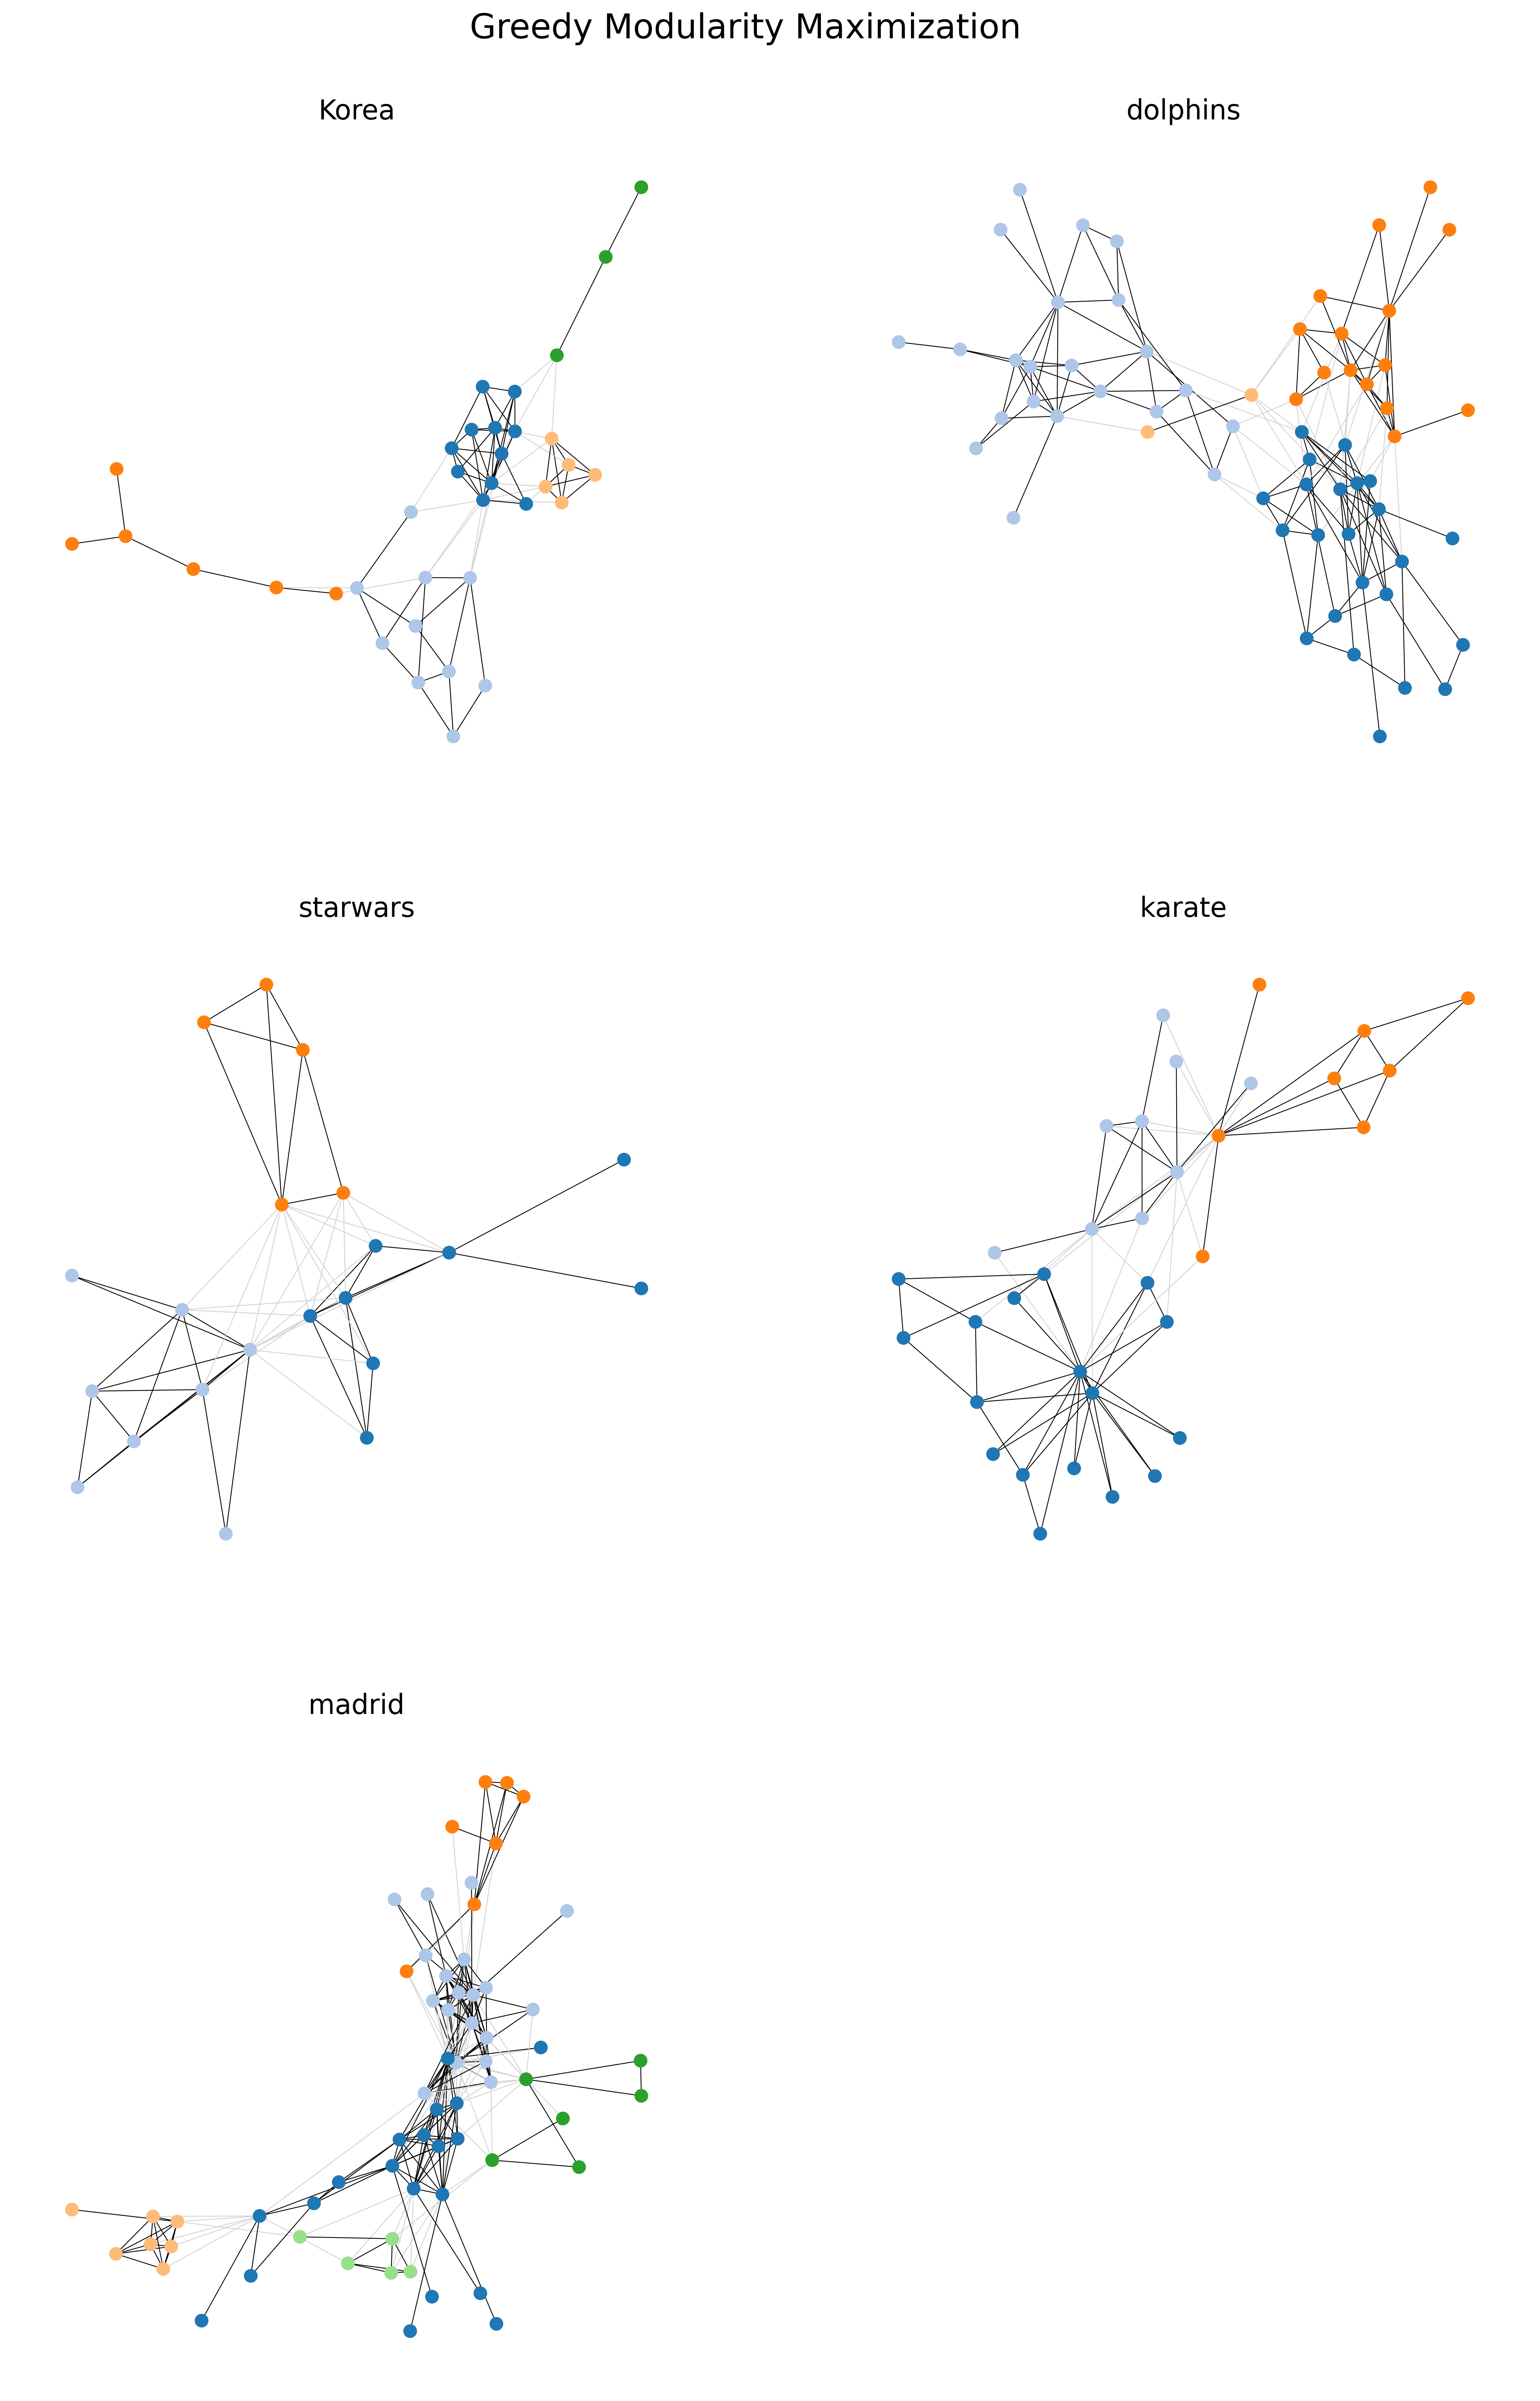

In [76]:
# a) greedy_modularity_maximization
communities_GMM = community_figure(3,2, data_lst, greedy_modularity_maximization, "Greedy Modularity Maximization")

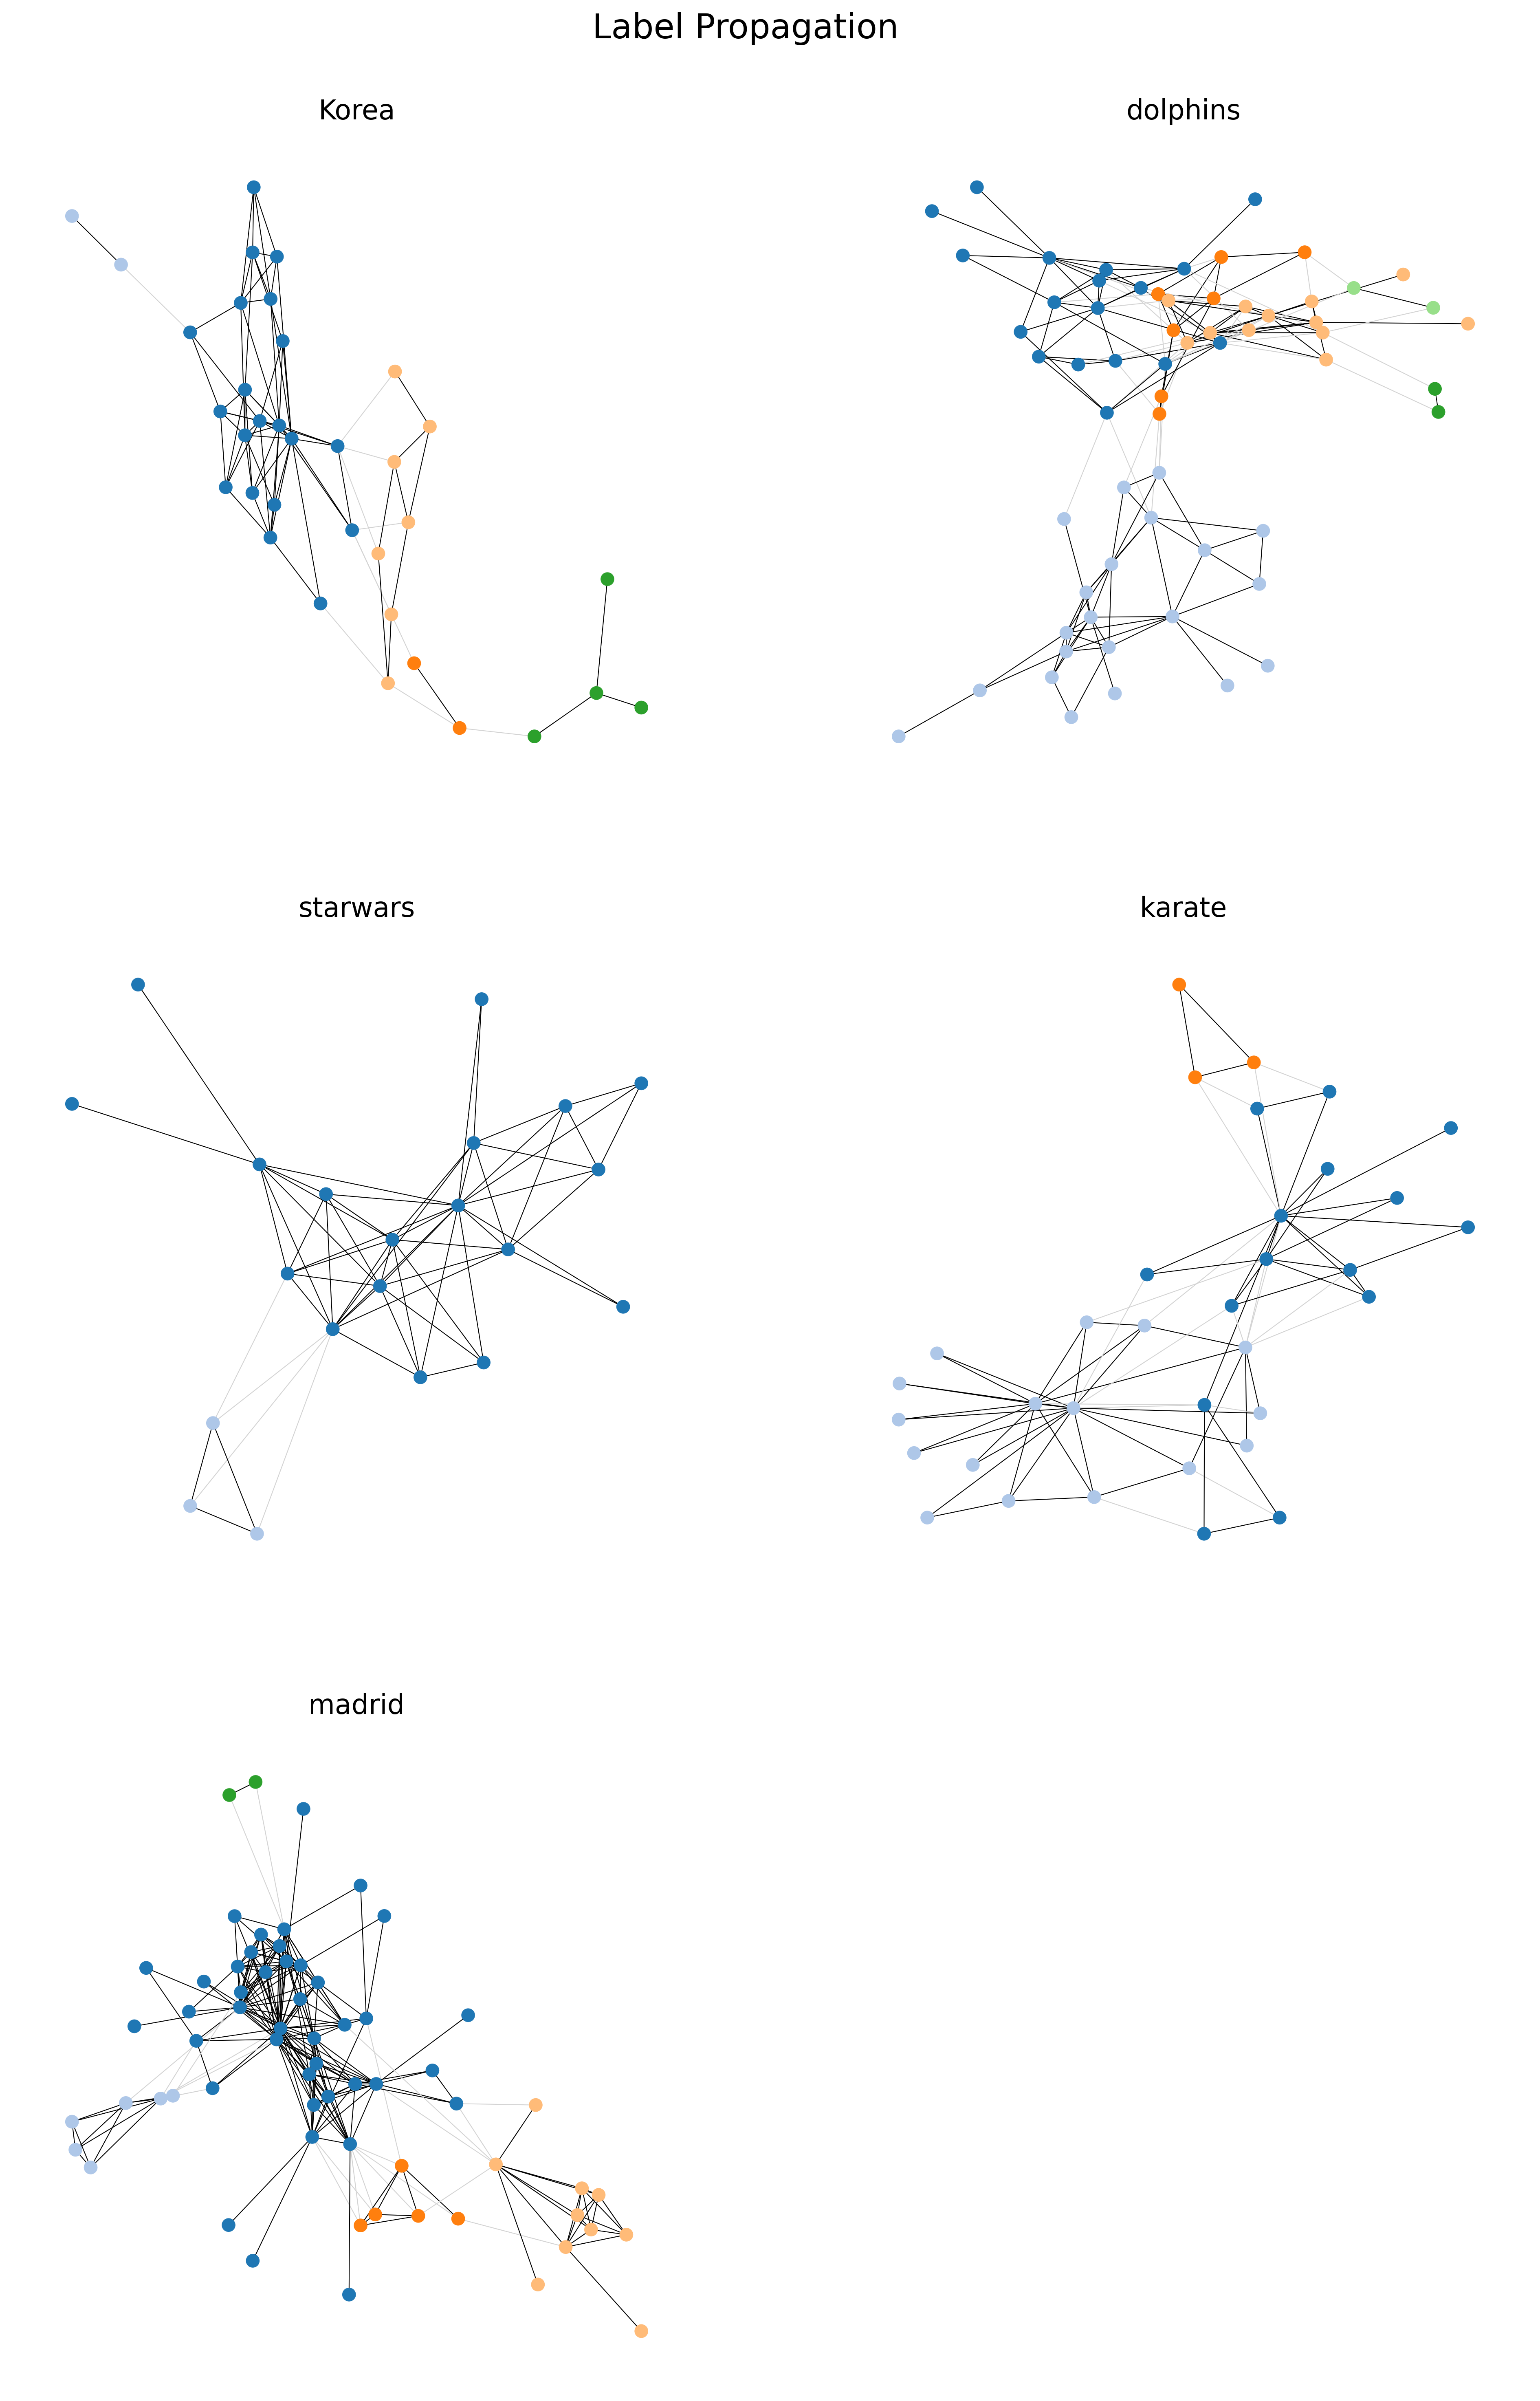

In [77]:
# a) label_propagation
communities_LP = community_figure(3,2, data_lst, label_propagation, "Label Propagation")

## Task 2
Randomise each network and repeat the exercise at task 1.

In [81]:
# we perform degree preserving randomization of the data
data_lst_R = [nx.algorithms.smallworld.random_reference(G, connectivity=True) for G in data_lst]

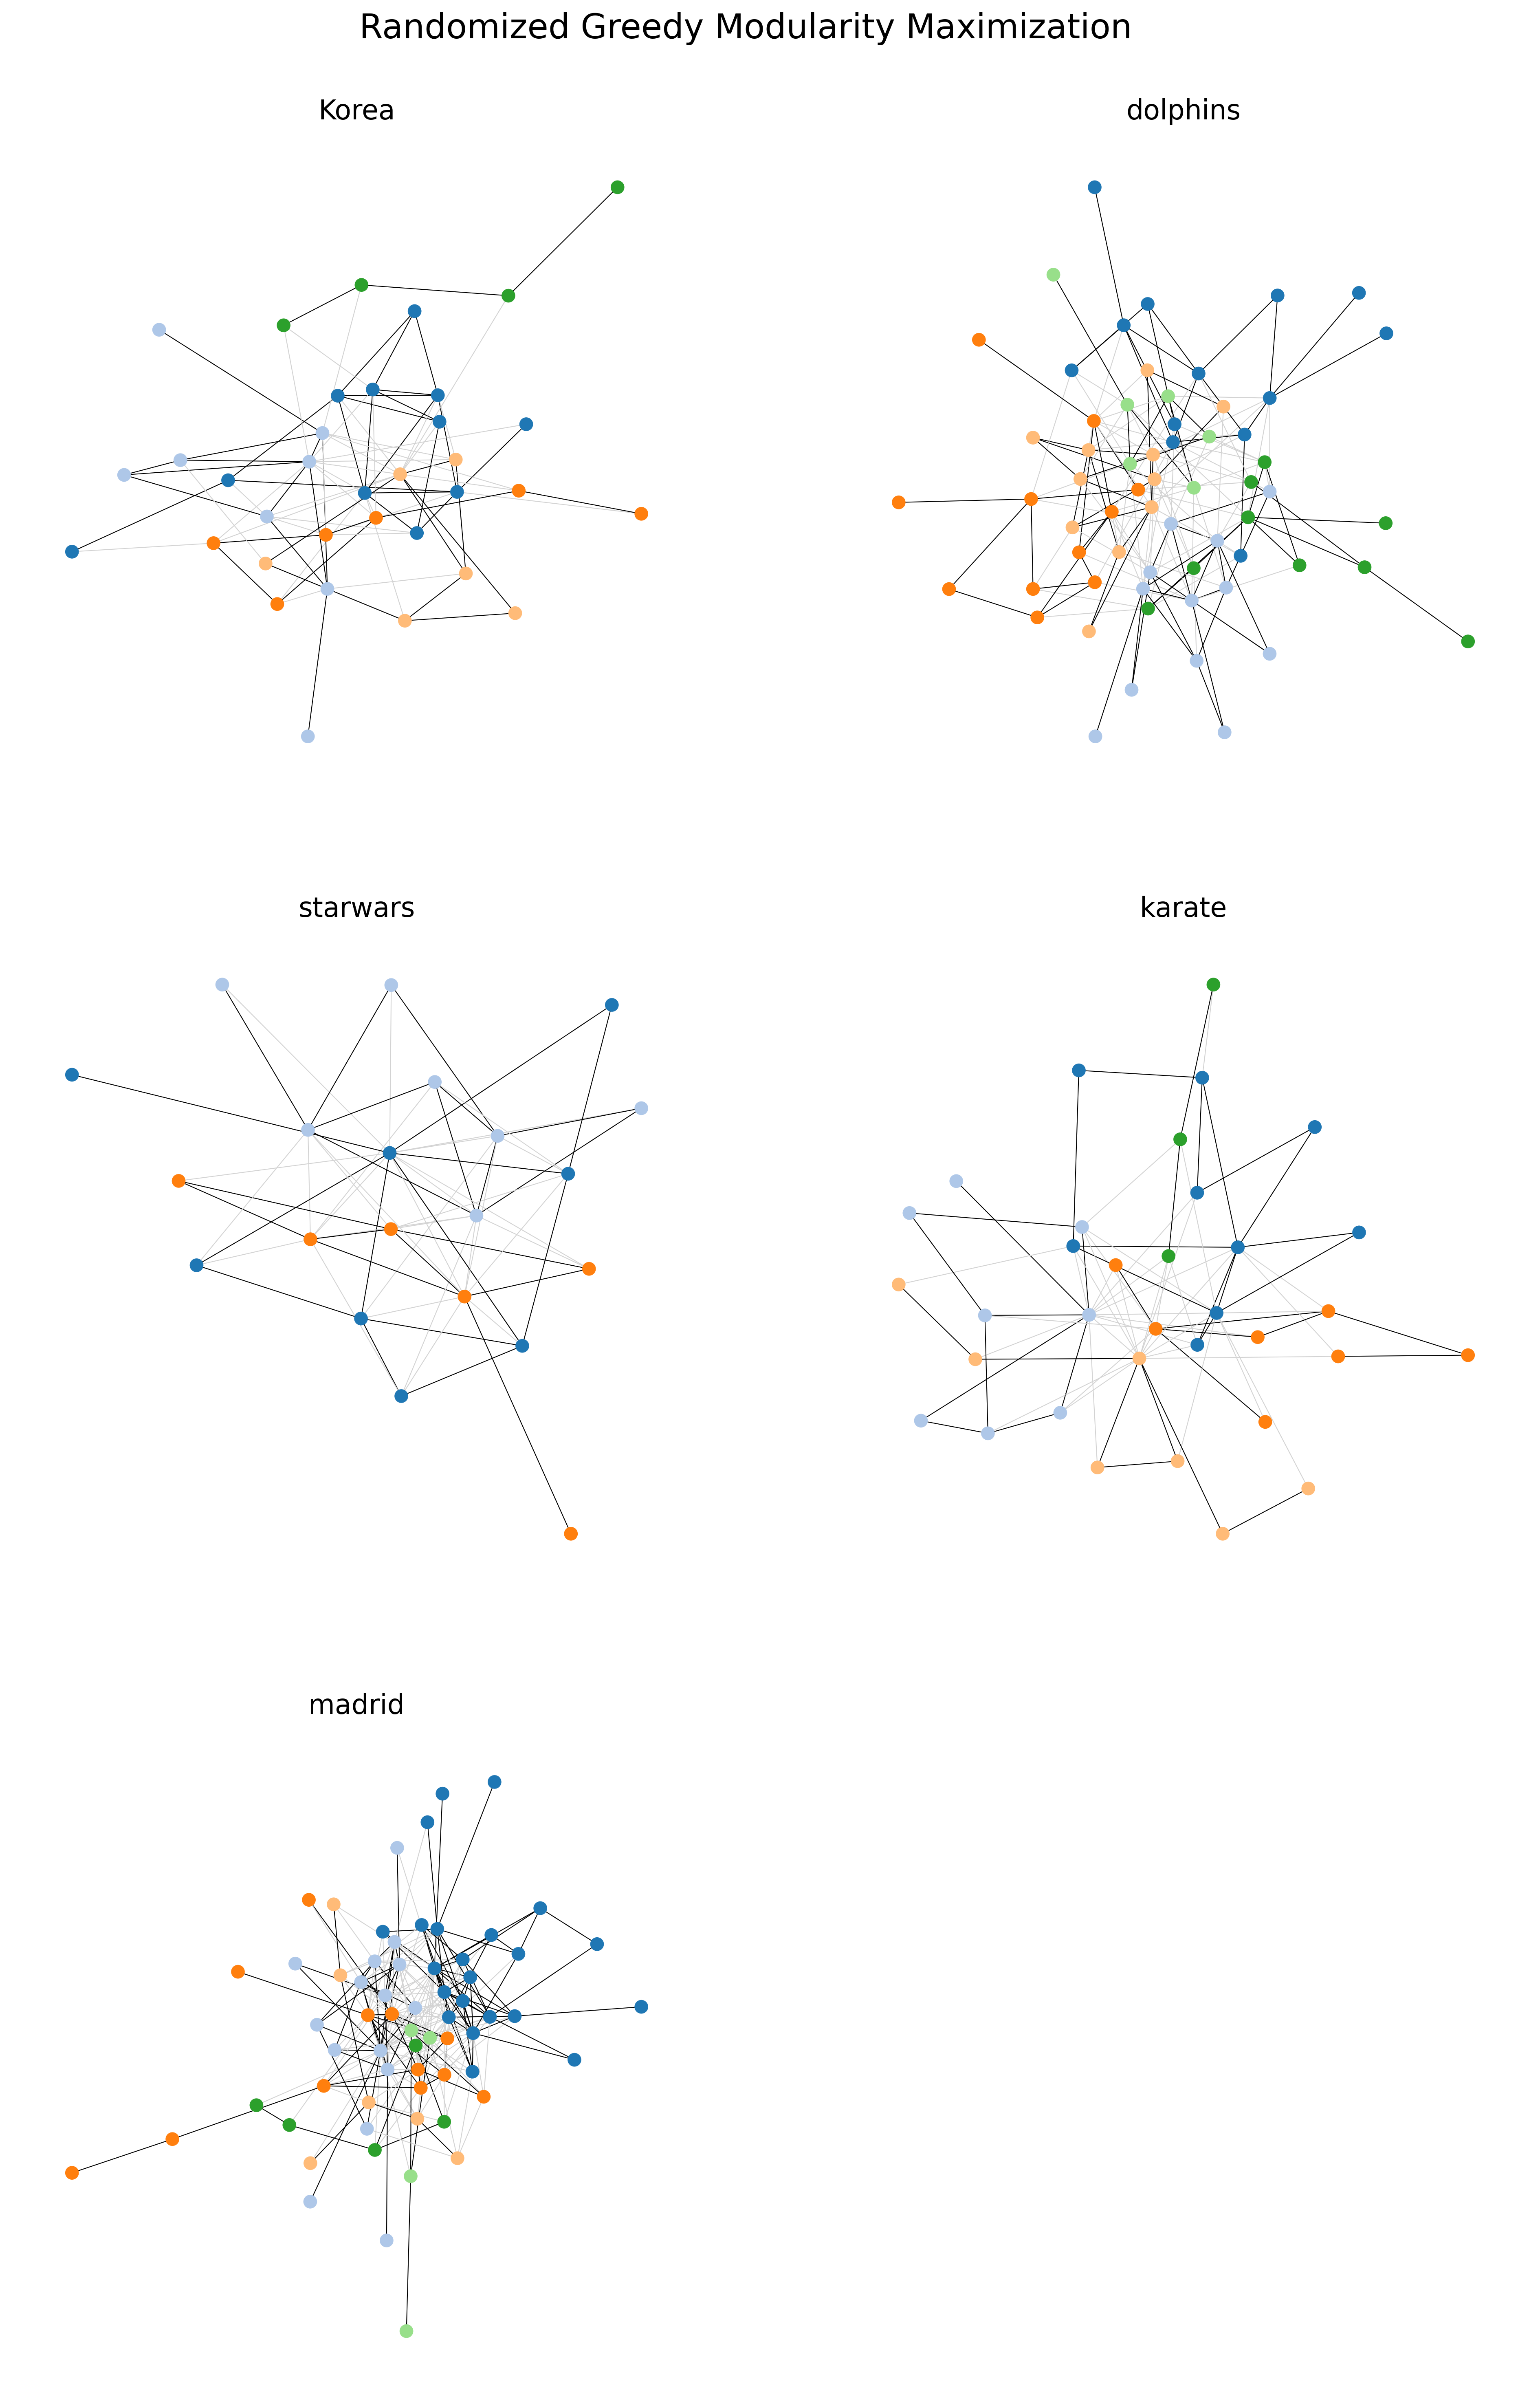

In [82]:
# 2a) greedy_modularity_maximization randomized
communities_GMM_R = community_figure(3,2, data_lst_R, greedy_modularity_maximization, "Randomized Greedy Modularity Maximization")

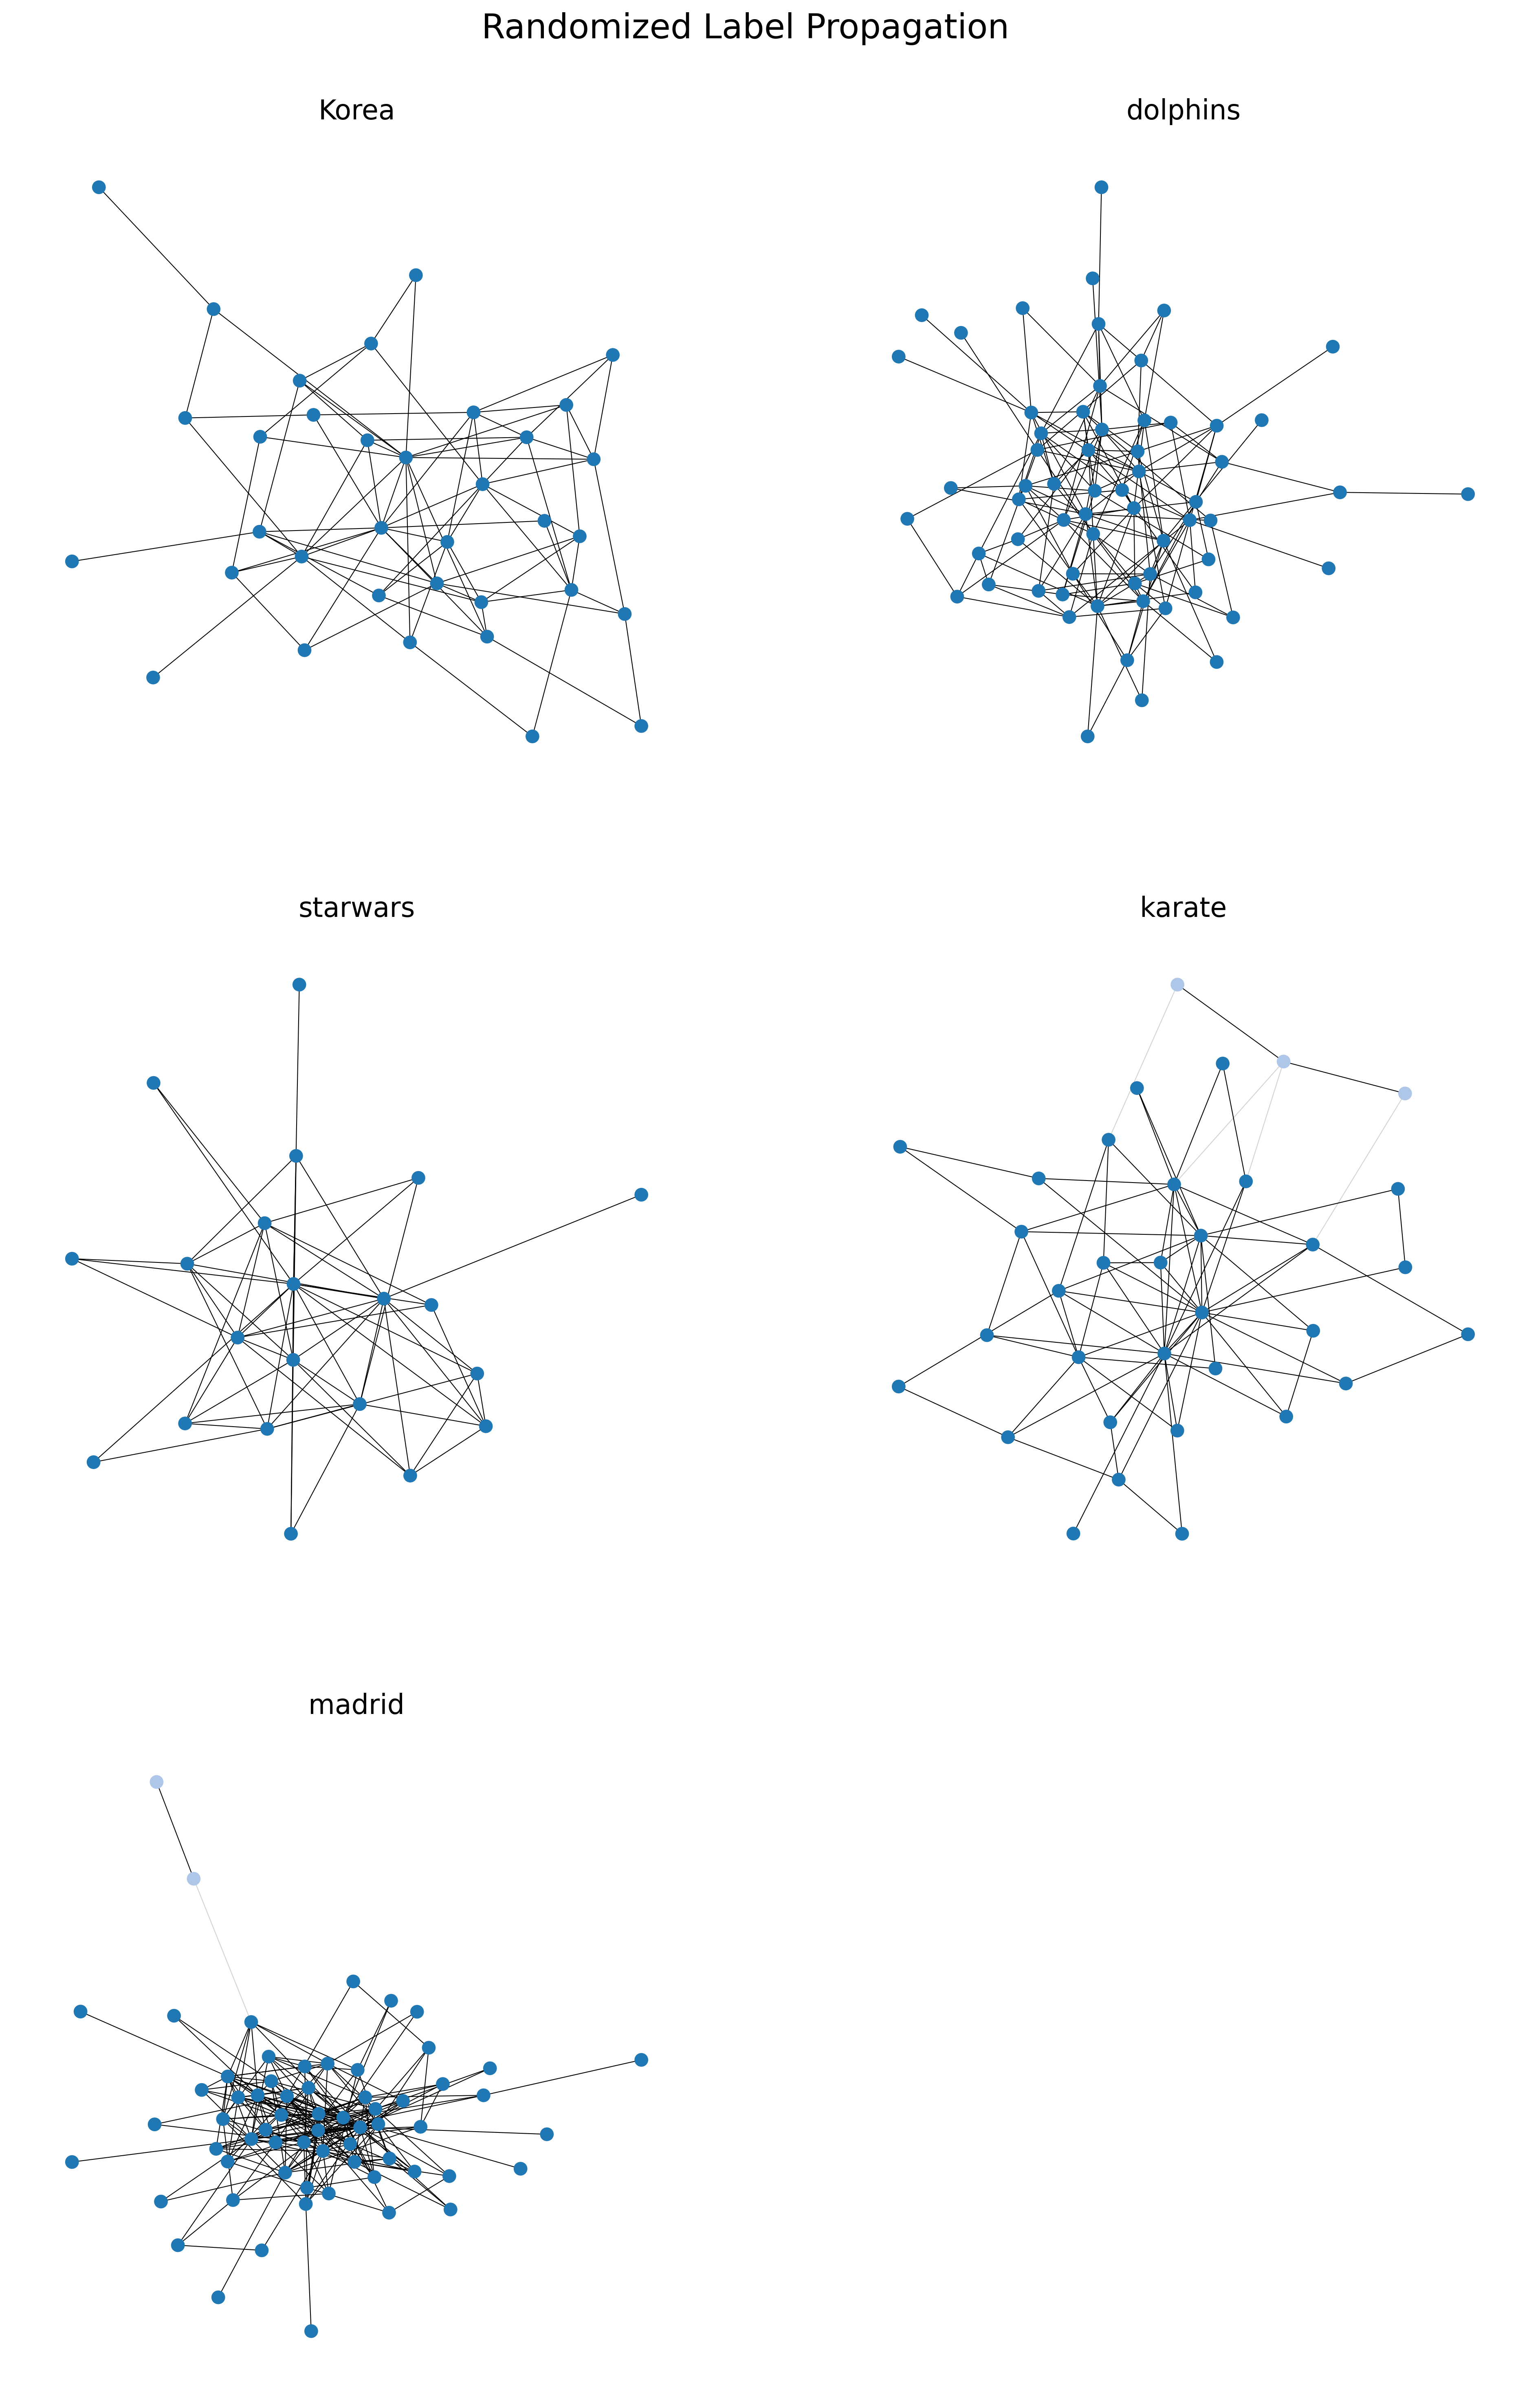

In [83]:
communities_LP_R = community_figure(3,2, data_lst_R, label_propagation, "Randomized Label Propagation")

### Interpretation
Compare the number of communities obtained before and after randomisation and the quality of community detection before and after randomisation.